# 382 isoleucinas que sobraban

¿Y si pudieras vivir con un aminoácido menos? Todos los organismos conocidos usan 20 aminoácidos canónicos para construir sus proteínas. El [Wang Lab de Columbia](https://github.com/wanglabcumc/Ec19) decidió probar si una *Escherichia coli* podía funcionar con 19 — quitándole la isoleucina. Para empezar, tenían que rediseñar el ribosoma: identificaron y reemplazaron **382 residuos de Ile** distribuidos en 50 proteínas ribosomales.

En este notebook recreamos ese conteo desde el FASTA público y exploramos cómo se distribuye Ile en el ribosoma — el dato que define el alcance del rediseño.

**Paper:** Toward life with a 19–amino acid alphabet through generative artificial intelligence design · *Science* (2026)
**DOI:** [10.1126/science.aeb5171](https://doi.org/10.1126/science.aeb5171)
**Datos:** [github.com/wanglabcumc/Ec19](https://github.com/wanglabcumc/Ec19) · `data/ecoli_ribosomal_genes.fasta`

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-16-19-aminoacidos-ec19/notebook.ipynb)


## El ribosoma como punto de partida

Para construir una bacteria sin isoleucina hay que reescribir todas sus proteínas esenciales sin ese aminoácido. El ribosoma — la maquinaria que fabrica proteínas — es el corazón del problema: si el ribosoma falla, la célula entera falla.

El equipo se centró en las **50 proteínas que forman el ribosoma de E. coli**. Tomaron las secuencias naturales (wild-type), contaron cuánta isoleucina contenían, y usaron modelos generativos de IA (basados en lenguaje de proteínas y estructura) para rediseñar versiones sin Ile que siguieran plegándose y funcionando.

Aquí miramos solo lo primero: la materia prima del rediseño.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PROT_DESTACADA = 'rpsA'         # proteína a destacar en gráficas (la del outlier)
PROT_CONCENTRACION = 10         # top-N para "concentración de trabajo de rediseño"
FUENTE = 'Fuente: paper Science (2026), DOI 10.1126/science.aeb5171 | Datos: github.com/wanglabcumc/Ec19'
COLOR_DATOS = '#2563EB'         # azul CaM
COLOR_ALERTA = '#DC2626'        # rojo (outlier / Ile destacada)
COLOR_REFERENCIA = '#D97706'    # amber (mediana / referencia)
COLOR_SECUNDARIO = '#059669'    # emerald (datos comparativos)
COLOR_CONTEXTO = '#BBBBBB'      # gris (background)

# ── Imports ──
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local → GitHub raw fallback)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# ── Carga de datos ──
df_genes = pd.read_csv('datos/ribosomal_genes_ile.csv')
df_aa = pd.read_csv('datos/aa_composition_global.csv')

# ── Resumen ──
n_prot = len(df_genes)
n_ile_total = int(df_genes['ile_count'].sum())
n_residuos = int(df_genes['length_aa'].sum())
pct_ile_global = n_ile_total / n_residuos * 100
print(f'Proteínas ribosomales analizadas: {n_prot}')
print(f'Residuos totales: {n_residuos:,}'.replace(',', '.'))
print(f'Isoleucinas totales: {n_ile_total} ({pct_ile_global:.2f} % del total)')
print(f'Cross-check vs paper: el paper reporta 382 Ile → coincidencia exacta.')


Proteínas ribosomales analizadas: 50
Residuos totales: 6.815
Isoleucinas totales: 382 (5.61 % del total)
Cross-check vs paper: el paper reporta 382 Ile → coincidencia exacta.


## Cómo se reparten las 382 isoleucinas

Aquí está.


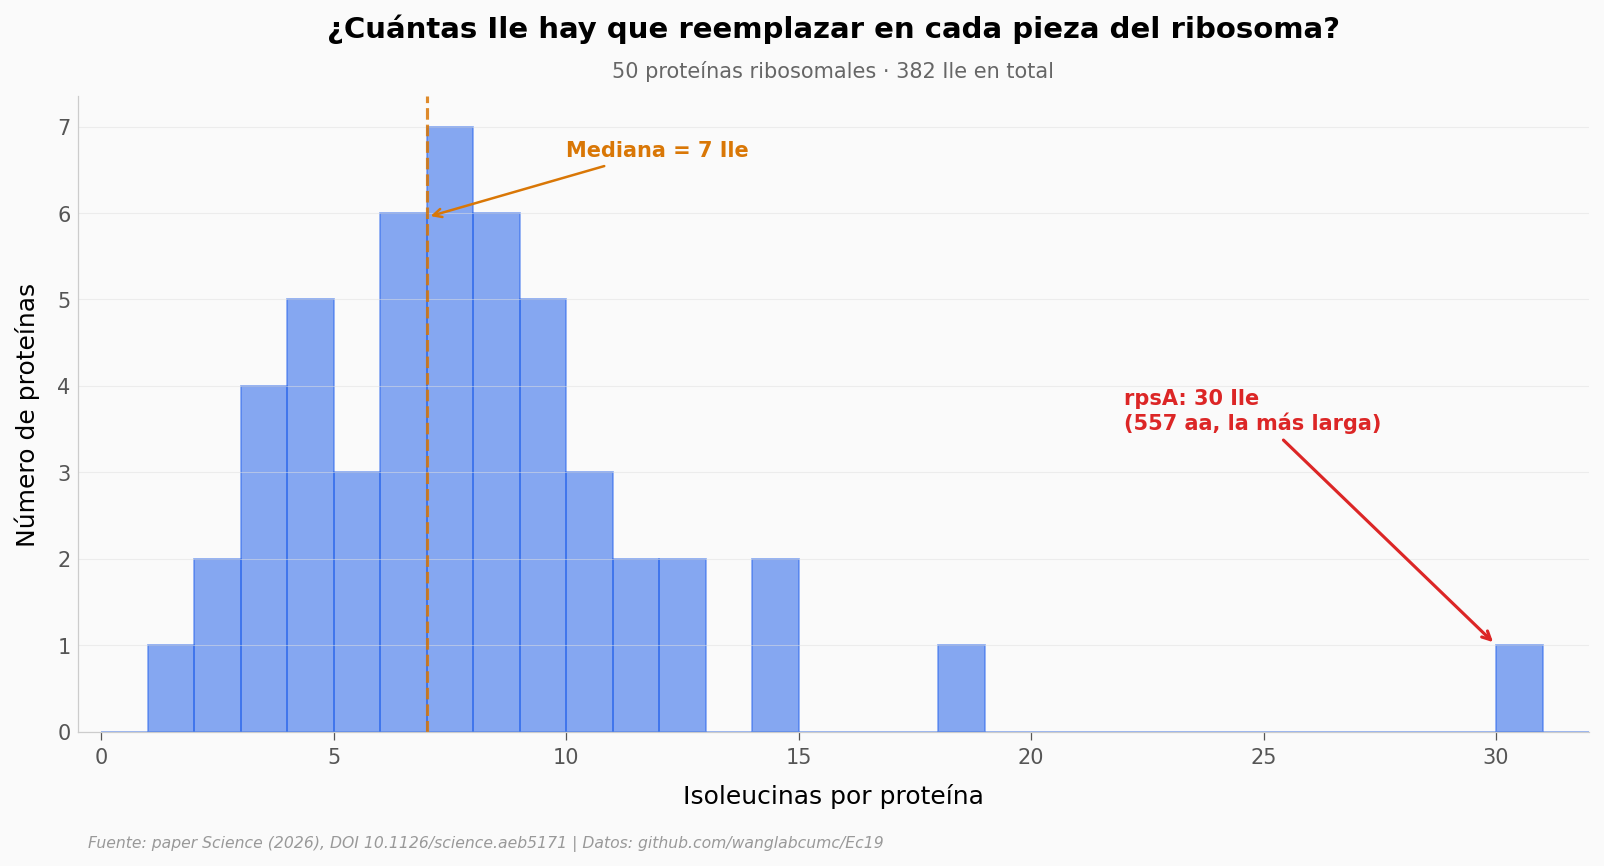

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ile_counts = df_genes['ile_count'].values
median = np.median(ile_counts)
mean = ile_counts.mean()

# Histograma
n, bins, patches = ax.hist(ile_counts, bins=np.arange(0, 33, 1),
                            color=COLOR_DATOS, alpha=0.55,
                            edgecolor=COLOR_DATOS, linewidth=0.8)

# Línea de mediana
ax.axvline(median, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.85)
ax.annotate(f'Mediana = {median:.0f} Ile',
            xy=(median, n.max()*0.85), xytext=(median+3, n.max()*0.95),
            fontsize=10, fontweight='bold', color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.2))

# Outlier rpsA
outlier_row = df_genes.loc[df_genes['ile_count'].idxmax()]
ax.annotate(f"{outlier_row['gene_name']}: {int(outlier_row['ile_count'])} Ile\n(557 aa, la más larga)",
            xy=(outlier_row['ile_count'], 1), xytext=(22, n.max()*0.5),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_xlabel('Isoleucinas por proteína')
ax.set_ylabel('Número de proteínas')
ax.set_title('¿Cuántas Ile hay que reemplazar en cada pieza del ribosoma?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{n_prot} proteínas ribosomales · {n_ile_total} Ile en total',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.5, 32)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_ile_por_proteina.png', dpi=200, bbox_inches='tight')
plt.show()


La distribución se inclina fuertemente hacia la izquierda: la mediana es **7 isoleucinas por proteína** y la mayoría se concentra entre 4 y 9. Pero hay un outlier extremo: una proteína sola (`rpsA`, la subunidad más larga del ribosoma) acumula 30 Ile — cuatro veces el promedio. Removerle la isoleucina a `rpsA` es, por sí mismo, casi el 8 % del trabajo total del rediseño.

La asimetría importa: si Ile estuviera repartido uniformemente, bastaría una receta general. Como no lo está, cada proteína requiere su propio plan.

## Las 10 proteínas que concentran el rediseño

¿En cuántas proteínas se concentra realmente el trabajo? Veamos las que más Ile tienen.

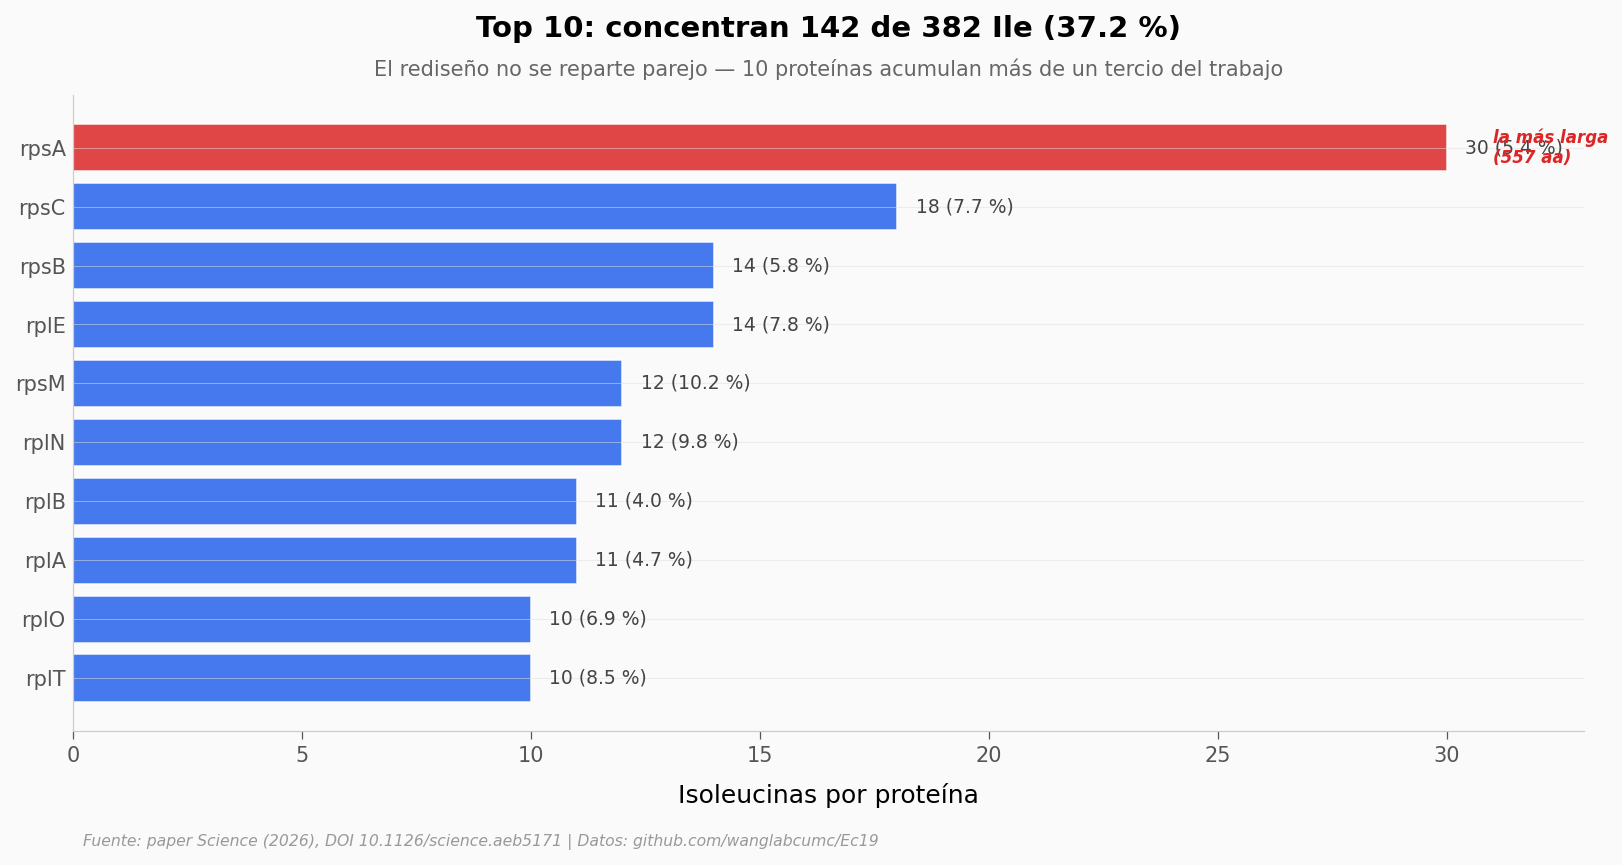


Top 10 concentra 142/382 Ile = 37.2 %
rpsA sola: 30 Ile = 7.9 % del rediseño


In [3]:
top10 = df_genes.nlargest(PROT_CONCENTRACION, 'ile_count').sort_values('ile_count')
top10_sum = int(top10['ile_count'].sum())
top10_pct = top10_sum / n_ile_total * 100

fig, ax = plt.subplots(figsize=(13, 5.5))

colors = [COLOR_ALERTA if g == PROT_DESTACADA else COLOR_DATOS for g in top10['gene_name']]
bars = ax.barh(top10['gene_name'], top10['ile_count'], color=colors,
               alpha=0.85, edgecolor='white', linewidth=0.8)

# Etiquetas con conteo + porcentaje de la proteína
for bar, count, pct in zip(bars, top10['ile_count'], top10['ile_pct']):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f'{int(count)} ({pct:.1f} %)',
            va='center', fontsize=9, color='#444444')

ax.set_xlabel('Isoleucinas por proteína')
ax.set_title(f'Top {PROT_CONCENTRACION}: concentran {top10_sum} de {n_ile_total} Ile ({top10_pct:.1f} %)',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'El rediseño no se reparte parejo — 10 proteínas acumulan más de un tercio del trabajo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 33)

# Etiqueta inline sobre rpsA
rpsA_idx = list(top10['gene_name']).index(PROT_DESTACADA)
ax.text(31, rpsA_idx, 'la más larga\n(557 aa)', va='center', ha='left',
        fontsize=8, color=COLOR_ALERTA, fontweight='bold', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/top10_ile_por_proteina.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nTop {PROT_CONCENTRACION} concentra {top10_sum}/{n_ile_total} Ile = {top10_pct:.1f} %')
print(f'rpsA sola: {int(outlier_row["ile_count"])} Ile = {outlier_row["ile_count"]/n_ile_total*100:.1f} % del rediseño')


## ¿Es Ile especialmente abundante en el ribosoma?

Si Ile fuera uno de los aminoácidos más usados, su eliminación sería desproporcionadamente difícil. Pero si es minoritario, ¿por qué se eligió a Ile y no a otro? Veamos cómo se compara con los demás aminoácidos en estas mismas 50 proteínas.

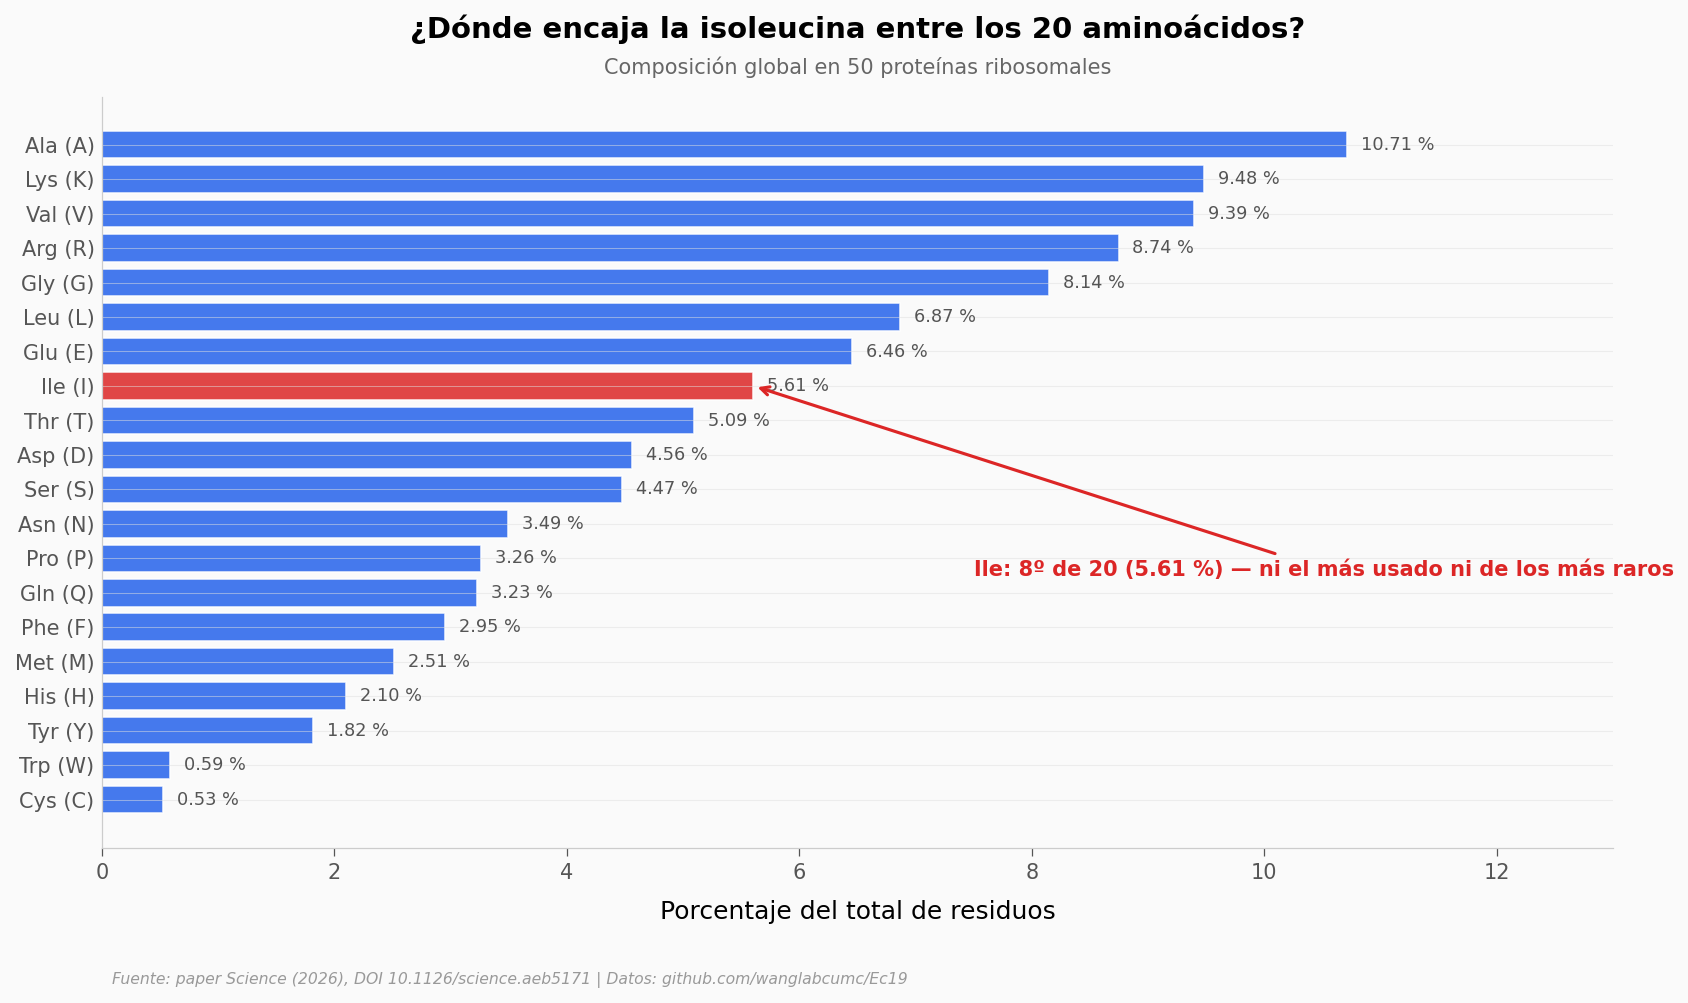

In [4]:
# Normalizar nombre de columna (CSV usa pct_of_total)
df_aa = df_aa.rename(columns={'pct_of_total': 'pct'})

# Ordenar por count asc para que barh muestre el más abundante arriba
df_aa_sorted = df_aa.sort_values('count', ascending=True).reset_index(drop=True)
df_aa_sorted['rank'] = df_aa_sorted['count'].rank(ascending=False).astype(int)

# Diccionario aa → nombre completo
aa_names = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'E': 'Glu', 'Q': 'Gln', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
}
df_aa_sorted['label'] = df_aa_sorted['amino_acid'].map(lambda a: f'{aa_names[a]} ({a})')

fig, ax = plt.subplots(figsize=(13, 6.5))

colors = [COLOR_ALERTA if a == 'I' else COLOR_DATOS for a in df_aa_sorted['amino_acid']]
bars = ax.barh(df_aa_sorted['label'], df_aa_sorted['pct'], color=colors,
               alpha=0.85, edgecolor='white', linewidth=0.8)

for bar, pct in zip(bars, df_aa_sorted['pct']):
    ax.text(bar.get_width() + 0.12, bar.get_y() + bar.get_height()/2,
            f'{pct:.2f} %', va='center', fontsize=8.5, color='#555555')

# Anotación sobre Ile
ile_pos = list(df_aa_sorted['amino_acid']).index('I')
ile_rank = int(df_aa_sorted.loc[ile_pos, 'rank'])
ax.annotate(f'Ile: 8º de 20 ({pct_ile_global:.2f} %) — ni el más usado ni de los más raros',
            xy=(df_aa_sorted.loc[ile_pos, 'pct'], ile_pos),
            xytext=(7.5, ile_pos - 5.5),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_xlabel('Porcentaje del total de residuos')
ax.set_title('¿Dónde encaja la isoleucina entre los 20 aminoácidos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Composición global en {n_prot} proteínas ribosomales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 13)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/composicion_global_aa.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Tan extremo es este alfabeto?

Ile no es el aminoácido más abundante (lo es Ala, con 10,71 %) ni de los más raros (Trp está en el último puesto con menos del 1,5 %). Está en mitad de la tabla: el octavo de veinte, con 5,61 % de los residuos. Suficientemente común para estar en casi todas las proteínas ribosomales — pero no tanto como para hacer el rediseño imposible.

¿Cómo se ve la concentración de Ile **por proteína**? Algunas tienen mucha más Ile de lo esperado para una proteína "promedio".

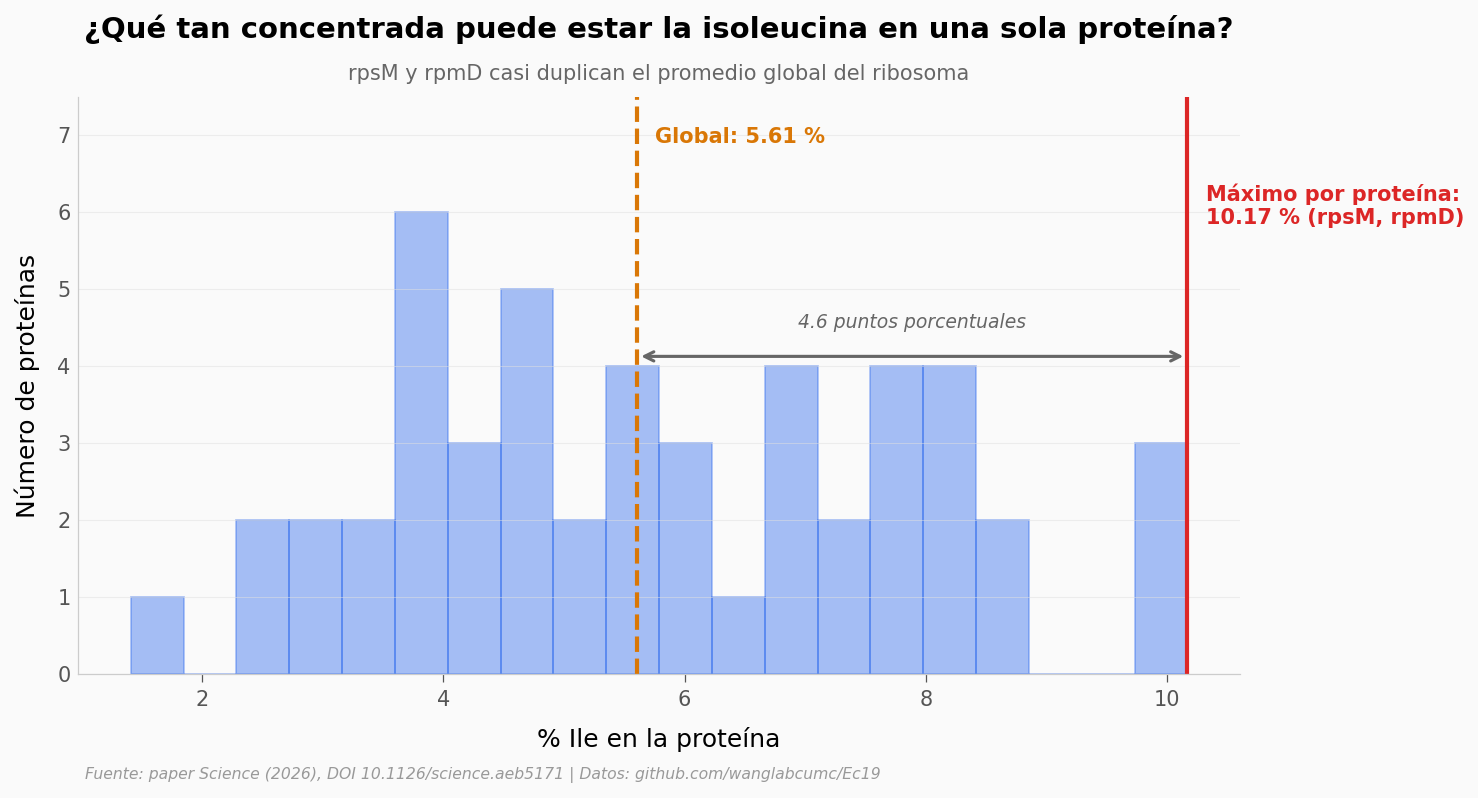

Promedio global de Ile: 5.61 %
Proteína con mayor % Ile: 10.17 % (casi 2× el promedio)
Proteínas con %Ile por encima del promedio: 25 de 50


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ile_pcts = df_genes['ile_pct'].values
n, bins, patches = ax.hist(ile_pcts, bins=20, color=COLOR_DATOS, alpha=0.4,
                            edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Línea: promedio global (5.61%)
ax.axvline(pct_ile_global, color=COLOR_REFERENCIA, linewidth=2.0, linestyle='--')
ax.text(pct_ile_global + 0.15, y_max*0.92,
        f'Global: {pct_ile_global:.2f} %', fontsize=10, color=COLOR_REFERENCIA,
        fontweight='bold')

# Línea: máximo por proteína (10.17% rpsM/rpmD)
max_pct = ile_pcts.max()
ax.axvline(max_pct, color=COLOR_ALERTA, linewidth=2.0)
ax.text(max_pct + 0.15, y_max*0.78,
        f'Máximo por proteína:\n{max_pct:.2f} % (rpsM, rpmD)',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

# Flecha bidireccional global ↔ máximo
ax.annotate('', xy=(max_pct, y_max*0.55), xytext=(pct_ile_global, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((pct_ile_global + max_pct)/2, y_max*0.6,
        f'{(max_pct - pct_ile_global):.1f} puntos porcentuales',
        ha='center', fontsize=9, color='#666666', style='italic')

ax.set_xlabel('% Ile en la proteína')
ax.set_ylabel('Número de proteínas')
ax.set_title('¿Qué tan concentrada puede estar la isoleucina en una sola proteína?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'rpsM y rpmD casi duplican el promedio global del ribosoma',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_pct_ile.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Promedio global de Ile: {pct_ile_global:.2f} %')
print(f'Proteína con mayor % Ile: {max_pct:.2f} % (casi 2× el promedio)')
print(f'Proteínas con %Ile por encima del promedio: {(df_genes["ile_pct"] > pct_ile_global).sum()} de {n_prot}')


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| El ribosoma de E. coli tiene 382 residuos de Ile distribuidos en 50 proteínas | ✅ | Recuento directo del FASTA público coincide exactamente con el headline del paper (diferencia = 0). |
| La distribución de Ile por proteína es asimétrica con outlier extremo (`rpsA` con 30 Ile) | ✅ | min=1, mediana=7, max=30. `rpsA` es 4× la media porque es la más larga (557 aa). |
| Las 10 proteínas con más Ile concentran 142/382 = 37 % del trabajo de rediseño | ✅ | Cálculo directo sobre el FASTA. |
| Ile es el 8º aminoácido más usado en el ribosoma (5,61 % del total) | ✅ | Conteo global sobre 6.815 residuos. Por debajo de Ala, Lys, Val, Arg, Gly, Leu, Glu. |
| El equipo reemplazó sistemáticamente los 382 Ile y produjo una *E. coli* viable y evolutivamente estable sin Ile en el ribosoma | ✅ | Afirmación directa del paper ("We systematically replaced... to produce a viable, evolutionarily stable cell"). Verificación experimental del laboratorio, no de este notebook. |
| Modelos de lenguaje proteico y de estructura fueron necesarios para diseñar las variantes funcionales sin Ile | ✅ | El paper lo declara como necesidad técnica ("PLMs and structure-based models were necessary"). |
| Este trabajo crea un organismo completo de 19 aminoácidos | ⚠️ | Matiz importante: el paper rediseña el **ribosoma** sin Ile y demuestra una célula viable con esos componentes. Reemplazar Ile en TODO el proteoma de E. coli queda como trabajo futuro — el propio paper lo enmarca como *roadmap*. |

> **Limitaciones:** El notebook explora la composición de Ile **antes** del rediseño. No verifica la viabilidad de las variantes diseñadas (eso requiere experimentos de laboratorio reportados en el paper). El FASTA pública del repo incluye únicamente las 50 secuencias wild-type — no las versiones rediseñadas ni los datos de crecimiento.

## Ahora tú

Tres preguntas para explorar con los datos:

1. **¿Y si en vez de Ile hubieran quitado Val?** Val (valina) es químicamente parecida a Ile — ambas son hidrofóbicas y ramificadas. ¿Cuántos residuos habría que reemplazar?
2. **¿Es la longitud lo que predice cuántas Ile tendrá una proteína?** Si lo es, no hay nada "extraordinario" en `rpsA`. Calcula la correlación entre longitud y conteo de Ile.
3. **¿Hay proteínas que apenas tengan Ile?** Mira el extremo opuesto: las que el rediseño casi no tocó.

La celda siguiente responde la pregunta 1 — modifica el código para responder las otras.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Cuánto trabajo habría sido quitar Val en vez de Ile?

n_val_total = int(df_genes['val_count'].sum())
pct_val_global = n_val_total / n_residuos * 100

print(f'Si hubieran elegido Val en vez de Ile:')
print(f'  - Residuos a reemplazar: {n_val_total} (vs {n_ile_total} de Ile)')
print(f'  - Porcentaje global: {pct_val_global:.2f} % (vs {pct_ile_global:.2f} % de Ile)')
print(f'  - Trabajo extra: {n_val_total - n_ile_total} residuos más ({(n_val_total/n_ile_total - 1)*100:.0f} %)')
print()
print('Val es más abundante en el ribosoma → un alfabeto sin Val sería un rediseño más grande.')
print('Ile probablemente se eligió por una combinación de ser dispensable y minimizar el alcance.')

# Pista para pregunta 2:
# from scipy import stats
# r, p = stats.spearmanr(df_genes['length_aa'], df_genes['ile_count'])
# print(f'\nCorrelación longitud ↔ Ile: ρ = {r:.3f}, p = {p:.4f}')

# Pista para pregunta 3:
# print(df_genes.nsmallest(5, 'ile_count')[['gene_name', 'length_aa', 'ile_count', 'ile_pct']])


Si hubieran elegido Val en vez de Ile:
  - Residuos a reemplazar: 640 (vs 382 de Ile)
  - Porcentaje global: 9.39 % (vs 5.61 % de Ile)
  - Trabajo extra: 258 residuos más (68 %)

Val es más abundante en el ribosoma → un alfabeto sin Val sería un rediseño más grande.
Ile probablemente se eligió por una combinación de ser dispensable y minimizar el alcance.


---

## Fuentes

**Paper**: [Toward life with a 19–amino acid alphabet through generative artificial intelligence design](https://doi.org/10.1126/science.aeb5171)  
*Science, 2026-04-30 · paywall*

**Dataset canónico**: [Code accompanying the paper — data/ecoli_ribosomal_genes.fasta (50 E. coli ribosomal gene wild-type sequences)](https://github.com/wanglabcumc/Ec19)  
*GitHub (wanglabcumc/Ec19) — secuencias FASTA wild-type del ribosoma*

**Datos del pipeline computacional**: [Zenodo](https://doi.org/10.5281/zenodo.18155920) · [Zenodo](https://doi.org/10.5281/zenodo.18202555)

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · *Notebook reproducible — todos los datos provienen del FASTA público del Wang Lab.*